# Лабораторная работа №4

## Условие

Вариант №14

Распределения:

$$\mathbf{X} \sim R(0, 10)$$
$$\mathbf{Y} \sim N(5, 3)$$

Объём выборки:

$$ n = 200 $$

## Импорты

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
from scipy import stats
from time import time
from IPython.display import display, Markdown  # для вывода формул в консоль
import pandas as pd


## Определения

In [7]:
a1, b1 = 0, 10
m2, std2 = 5, 3
n = 200

In [3]:
def mprint(*strings):
    for s in strings:
        display(Markdown(s))


np.random.seed(int(time()))
plt.rc("text", usetex=True)
plt.rc(
    "text.latex",
    preamble=r"""
\usepackage[english, russian]{babel}
\usepackage[utf8]{inputenc}
""",
)
plt.style.use("seaborn-v0_8")

In [4]:
def dataframe_to_markdown(df):
    if df.index.name is None:
        first_cell = "Index"
    elif df.columns.name is None:
        first_cell = df.index.name
    else:
        first_cell = df.index.name + "\\" + df.columns.name
    markdown_table = "| " + first_cell + " | " + " | ".join(df.columns) + " |\n"
    markdown_table += "|---" * (len(df.columns) + 1) + "|\n"  # Учитываем индекс

    for index, row in df.iterrows():
        row_values = [str(round(val, 2) if type(val) != str else val) for val in row]
        markdown_table += f"| {index} | " + " | ".join(row_values) + " |\n"

    return markdown_table

In [5]:
alpha = 0.05


def verdict(alpha, p_value):
    if alpha > p_value:
        return "$H_0$ отклоняется"
    else:
        return "$H_0$ принимается"

## 1. Исходные данные

In [8]:
X = np.random.uniform(a1, b1, n)
Y = np.random.normal(m2, std2, n)

mprint(f"$X$: {X[:10].round(2)}")
mprint(f"$Y$: {Y[:10].round(2)}")

$X$: [0.92 8.7  4.26 0.38 7.04 0.67 3.31 8.07 8.12 7.75]

$Y$: [ 2.26  1.38  2.99 -0.58  4.16  3.78  9.5   2.44  7.97  5.58]

## 2. Математические формулы

### 2.1. Коэффициент корреляции Пирсона

Используется для количественных переменных.

$$
r_{XY} =
\frac{
\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})
}{
\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2}
\sqrt{\sum_{i=1}^{n} (y_i - \bar{y})^2}
}
$$

Эквивалентная форма:

$$
r_{XY} = \frac{\operatorname{cov}(X,Y)}{\sigma_X \sigma_Y}
$$

---

### 2.2. Коэффициент корреляции Спирмена

Основан на рангах, устойчив к выбросам.

1. Сначала каждому $x_i$ и $y_i$ присваиваются ранги $R(x_i)$ и $R(y_i)$.
2. Применяется формула Пирсона к рангам:

$$
\rho_{XY} =
\frac{
\sum_{i=1}^{n} (R(x_i) - \overline{R_x})(R(y_i) - \overline{R_y})
}{
\sqrt{\sum_{i=1}^{n} (R(x_i) - \overline{R_x})^2}
\sqrt{\sum_{i=1}^{n} (R(y_i) - \overline{R_y})^2}
}
$$

Если нет совпадающих рангов, используется упрощённая формула:

$$
\rho_{XY} = 1 - \frac{6\sum_{i=1}^{n} d_i^2}{n(n^2 - 1)}
$$

где

$$
d_i = R(x_i) - R(y_i).
$$

---

### 2.3. Коэффициент $\tau$ Кендалла

Основан на сравнении пар наблюдений.

Обозначим:

- $C$ — число согласованных пар  
- $D$ — число несогласованных пар  

Формула для $\tau$:

$$
\tau = \frac{C - D}{\tfrac{1}{2}n(n - 1)}
$$

Более строгая общая формула с учётом связей (используется SciPy):

$$
\tau =
\frac{C - D}
{\sqrt{(C + D + T_x)(C + D + T_y)}}
$$

где

$$
T_x,\, T_y \text{ — количества связанных пар по } X \text{ и } Y.
$$


### Выборочные характеристики

In [12]:
mean_X = X.mean()
S_X = X.var(ddof=1)

mean_Y = Y.mean()
S_Y = Y.var(ddof=1)


r_XY = stats.pearsonr(X,Y)[0]
rs_XY = stats.spearmanr(X,Y)[0]
rk_XY = stats.kendalltau(X,Y)[0]


mprint(f"$\\overline{{x}} =$ {mean_X:.2f}, $s_X^2 =$ {S_X:.2f}")
mprint(f"$\\overline{{y}} =$ {mean_Y:.2f}, $s_Y^2 =$ {S_Y:.2f}")

mprint(
    f"$r_{{XY}} =$ {r_XY:.2f}, $\\rho_{{XY}} =$ {rs_XY:.2f}, $\\tau_{{XY}} =$ {rk_XY:.2f}"
)

$\overline{x} =$ 4.97, $s_X^2 =$ 8.89

$\overline{y} =$ 5.09, $s_Y^2 =$ 9.22

$r_{XY} =$ -0.02, $\rho_{XY} =$ -0.01, $\tau_{XY} =$ -0.01

## t-статистика для корреляции Пирсона

Формула преобразования коэффициента корреляции \( r \) в t-статистику:

$$
t = r \cdot \sqrt{\frac{n - 2}{1 - r^{2}}}
$$

где:

- \( r \) — коэффициент корреляции Пирсона,
- \( n \) — размер выборки,
- \( t \) — t-статистика,
- распределение статистики — *t-распределение с \(n - 2\) степенями свободы*.


### Проверка значимости коэффициентов корреляции

In [15]:
z_r_XY = r_XY * sqrt(n - 2) / sqrt(1 - r_XY**2)
p_r_XY = stats.pearsonr(X, Y)[1]

z_rs_XY = rs_XY * sqrt(n - 2) / sqrt(1 - rs_XY**2)
p_rs_XY = stats.spearmanr(X, Y)[1]

z_rk_XY = rk_XY * sqrt(9 * n * (n + 1)) / sqrt(2 * (2 * n + 5))
p_rk_XY = stats.kendalltau(X, Y)[1]

mprint(
    r"### Проверка значимости КК",
    r"---",
    r"### $r_{XY}$",
    f"$H_0$: $r_{{XY}} = 0$, $H_1$: $r_{{XY}} \\neq 0$",
    f"$z_{{выб}} =$ {z_r_XY:.2f}, ",
    f"$p =$ {p_r_XY:.2f}",
    verdict(alpha, p_r_XY),
    r"---",
    r"### $\rho_{XY}$",
    f"$H_0$: $\\rho_{{XY}} = 0$, $H_1$: $\\rho_{{XY}} \\neq 0$",
    f"$z_{{выб}} =$ {z_rs_XY:.2f}, ",
    f"$p =$ {p_rs_XY:.2f}",
    verdict(alpha, p_rs_XY),
    r"---",
    r"### $\tau_{XY}$",
    f"$H_0$: $\\tau_{{XY}} = 0$, $H_1$: $\\tau_{{XY}} \\neq 0$",
    f"$z_{{выб}} =$ {z_rk_XY:.2f}, ",
    f"$p =$ {p_rk_XY:.2f}",
    verdict(alpha, p_rk_XY),
)

### Проверка значимости КК

---

### $r_{XY}$

$H_0$: $r_{XY} = 0$, $H_1$: $r_{XY} \neq 0$

$z_{выб} =$ -0.22, 

...

### $\tau_{XY}$

$H_0$: $\tau_{XY} = 0$, $H_1$: $\tau_{XY} \neq 0$

$z_{выб} =$ -0.15, 

$p =$ 0.88

$H_0$ принимается

## 2. Визуальное представление двумерной выборки

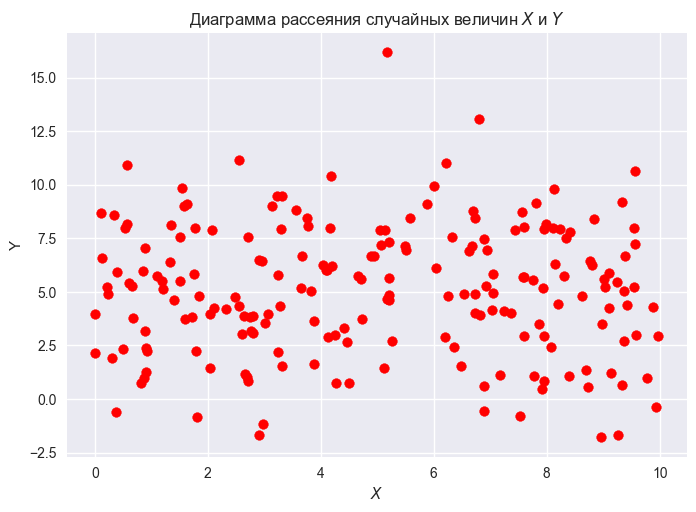

In [18]:
import matplotlib as mpl
mpl.rcParams['text.usetex'] = False


plt.scatter(X,Y,color = 'red')
plt.xlabel(r"$X$")
plt.ylabel(r"Y")
plt.title(r"Диаграмма рассеяния случайных величин $X$ и $Y$")
plt.show()

## 3. Проверка независимости методом таблиц сопряженности

Статистическая гипотеза: $H_0:\ F_y(y \mid X \in \Delta_1) = F_y(y \mid X \in \Delta_2) = \ldots = F_y(y \mid X \in \Delta_k) = F_y(y); \quad H':\ \exists i, j: F_Y(y \mid X \in \Delta_i) \neq F_Y(y \mid X \in \Delta_j)$

### Эмпирическая таблица сопряженности

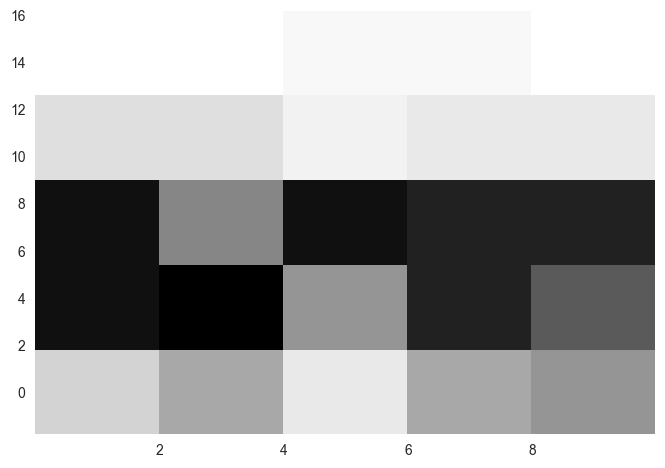

In [23]:
k = 5

emperical_table, bin_edges_X, bin_edges_Y, _ = plt.hist2d(X, Y, bins=k)

In [36]:
columns = [f"[{bin_edges_Y[i]:.2f}, {bin_edges_Y[i+1]:.2f})" for i in range(k - 1)] + [
    f"[{bin_edges_Y[-2]:.2f}, {bin_edges_Y[-1]:.2f}]"
]
indexes = [
    f"$\\Delta_{{{i+1}}} =$ [{bin_edges_X[i]:.2f}, {bin_edges_X[i+1]:.2f})"
    for i in range(k - 1)
] + [f"$\\Delta_{{{k}}} =$ [{bin_edges_X[-2]:.2f}, {bin_edges_X[-1]:.2f}]"]

emperical_table = pd.DataFrame(
    emperical_table,
    columns=pd.Index(columns, name="Y"),
    index=pd.Index(indexes, name="X"),
)
emperical_table



Y,"[-1.80, 1.80)","[1.80, 5.40)","[5.40, 8.99)","[8.99, 12.59)","[12.59, 16.18]"
X,,,,,
"$\Delta_{1} =$ [0.00, 2.00)",5.0,17.0,17.0,4.0,0.0
"$\Delta_{2} =$ [2.00, 3.99)",8.0,18.0,10.0,4.0,0.0
"$\Delta_{3} =$ [3.99, 5.99)",3.0,9.0,17.0,2.0,1.0
"$\Delta_{4} =$ [5.99, 7.98)",8.0,16.0,16.0,3.0,1.0
"$\Delta_{5} =$ [7.98, 9.98]",9.0,13.0,16.0,3.0,0.0


### Теоретическая таблица сопряженности

In [41]:
V1 = emperical_table.sum(axis=1).values
V1 = np.atleast_2d(V1).T
V1

array([[43.],
       [40.],
       [32.],
       [44.],
       [41.]])

In [42]:
V2 = emperical_table.sum(axis=0).values
V2 = np.atleast_2d(V2)
V2

array([[33., 73., 76., 16.,  2.]])

In [44]:
theoretical_table = pd.DataFrame(
    np.dot(V1, V2) / n,
    columns=pd.Index(columns, name="Y"),
    index=pd.Index(indexes, name="X"),
)
theoretical_table

Y,"[-1.80, 1.80)","[1.80, 5.40)","[5.40, 8.99)","[8.99, 12.59)","[12.59, 16.18]"
X,,,,,
"$\Delta_{1} =$ [0.00, 2.00)",7.095,15.695,16.34,3.44,0.43
"$\Delta_{2} =$ [2.00, 3.99)",6.600,14.600,15.20,3.20,0.40
"$\Delta_{3} =$ [3.99, 5.99)",5.280,11.680,12.16,2.56,0.32
"$\Delta_{4} =$ [5.99, 7.98)",7.260,16.060,16.72,3.52,0.44
"$\Delta_{5} =$ [7.98, 9.98]",6.765,14.965,15.58,3.28,0.41


### Проверка статистической гипотезы

In [46]:
res = stats.chi2_contingency(emperical_table)
z = res.statistic
p = res.pvalue

mprint(
    r"### $\chi^2$-test",
    r"$H_0:\ F_y(y \mid X \in \Delta_1) = F_y(y \mid X \in \Delta_2) = \ldots = F_y(y \mid X \in \Delta_k) = F_y(y)$",
    f"$z_{{выб}} =$ {z:.2f}",
    f"$p =$ {p:.2f}",
    verdict(alpha, p),
)

### $\chi^2$-test

$H_0:\ F_y(y \mid X \in \Delta_1) = F_y(y \mid X \in \Delta_2) = \ldots = F_y(y \mid X \in \Delta_k) = F_y(y)$

$z_{выб} =$ 12.17

$p =$ 0.73

$H_0$ принимается

## 4. Исследование корреляционной связи

Случайная величина $U = \lambda X + (1 - \lambda)Y,\ \lambda \in [0;1]$

Случайная величина $V = \lambda X^3 + (1 - \lambda)Y^3,\ \lambda \in [0;1]$

In [47]:
lambdas = np.linspace(0, 1, 10000)

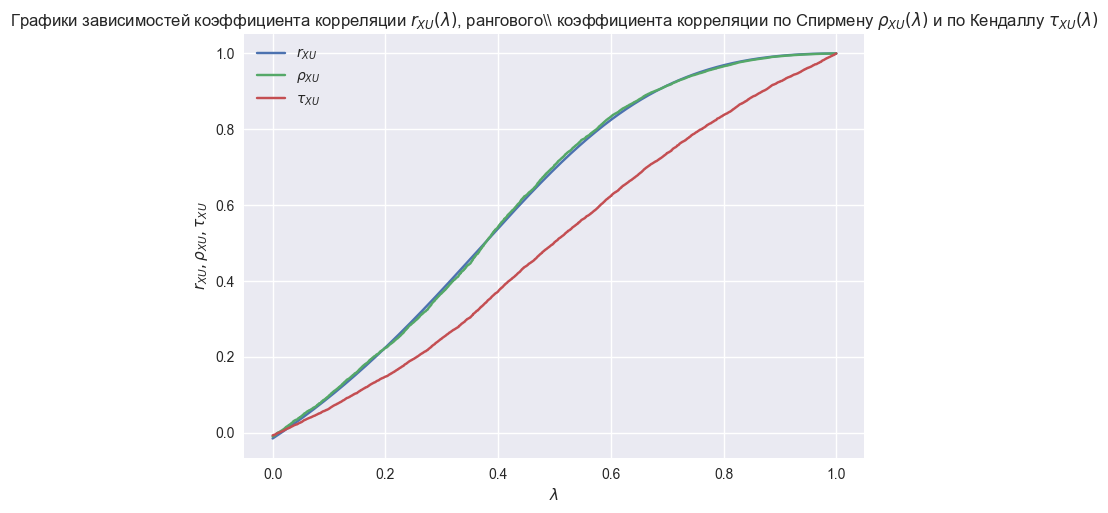

In [56]:
r_XU = []
rs_XU = []
rk_XU = []

for idx,i in enumerate(lambdas):
    U = i*X+(1-i)*Y
    
    r_XU.append(stats.pearsonr(X,U)[0])
    rs_XU.append(stats.spearmanr(X,U)[0])
    rk_XU.append(stats.kendalltau(X,U)[0])
    


plt.plot(lambdas,r_XU,label = r"$r_{XU}$")
plt.plot(lambdas, rs_XU, label=r"$\rho_{XU}$")
plt.plot(lambdas, rk_XU, label=r"$\tau_{XU}$")


plt.xlabel(r"$\lambda$")
plt.ylabel(r"$r_{XU}, \rho_{XU}, \tau_{XU}$")

plt.title(
    r"Графики зависимостей коэффициента корреляции $r_{XU}(\lambda)$, рангового\\ коэффициента корреляции по Спирмену $\rho_{XU}(\lambda)$ и по Кендаллу $\tau_{XU}(\lambda)$"
)
plt.legend()
plt.show()

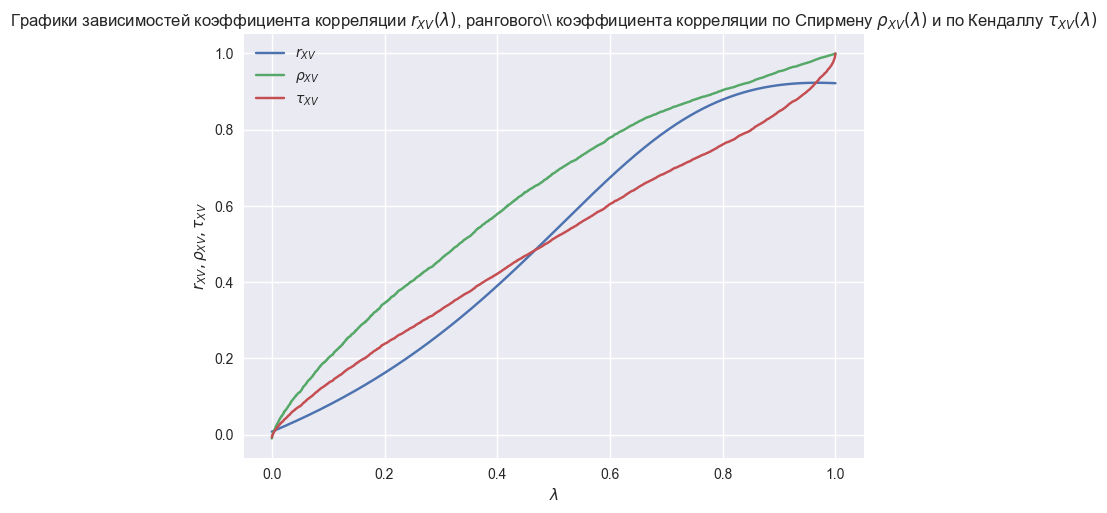

In [55]:
r_XV = []
rho_XV = []
tau_XV = []

for l in lambdas:
    V = l * X**3 + (1 - l) * Y**3
    r_XV.append([stats.pearsonr(X, V)[0]])
    rho_XV.append([stats.spearmanr(X, V)[0]])
    tau_XV.append([stats.kendalltau(X, V)[0]])

plt.plot(lambdas, r_XV, label=r"$r_{XV}$")
plt.plot(lambdas, rho_XV, label=r"$\rho_{XV}$")
plt.plot(lambdas, tau_XV, label=r"$\tau_{XV}$")
plt.xlabel(r"$\lambda$")
plt.ylabel(r"$r_{XV}, \rho_{XV}, \tau_{XV}$")
plt.title(
    r"Графики зависимостей коэффициента корреляции $r_{XV}(\lambda)$, рангового\\ коэффициента корреляции по Спирмену $\rho_{XV}(\lambda)$ и по Кендаллу $\tau_{XV}(\lambda)$"
)
plt.legend()
plt.show()

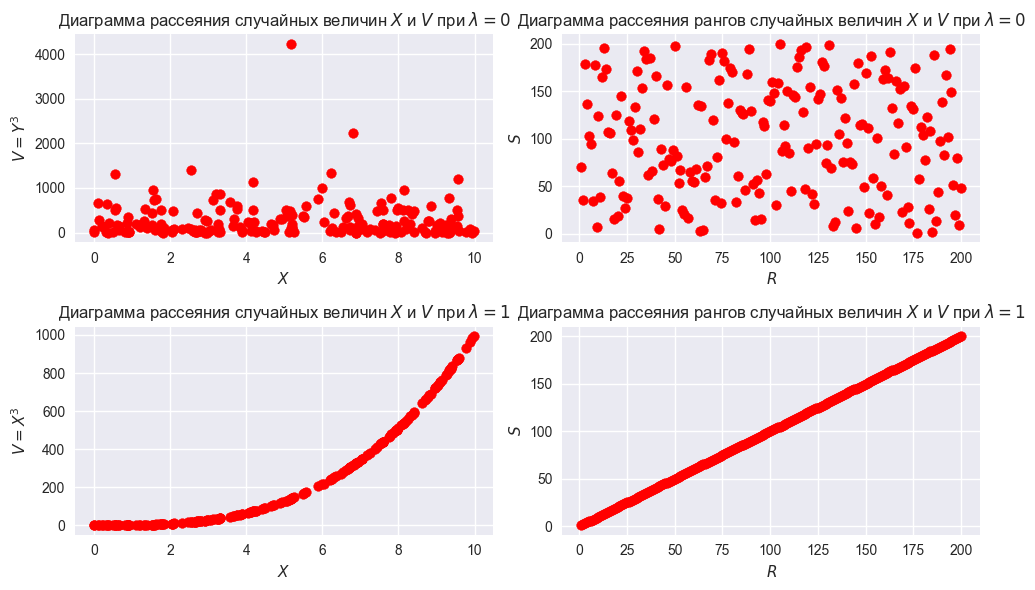

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

axes[0, 0].scatter(X, Y**3, color="red")
axes[0, 0].set_xlabel(r"$X$")
axes[0, 0].set_ylabel(r"$V = Y^3$")
axes[0, 0].set_title(
    r"Диаграмма рассеяния случайных величин $X$ и $V$ при $\lambda = 0$"
)

axes[0, 1].scatter(stats.rankdata(X), stats.rankdata(Y**3), color="red")
axes[0, 1].set_xlabel(r"$R$")
axes[0, 1].set_ylabel(r"$S$")
axes[0, 1].set_title(
    r"Диаграмма рассеяния рангов случайных величин $X$ и $V$ при $\lambda = 0$"
)


axes[1, 0].scatter(X, X**3, color="red")
axes[1, 0].set_xlabel(r"$X$")
axes[1, 0].set_ylabel(r"$V = X^3$")
axes[1, 0].set_title(
    r"Диаграмма рассеяния случайных величин $X$ и $V$ при $\lambda = 1$"
)

axes[1, 1].scatter(stats.rankdata(X), stats.rankdata(X**3), color="red")
axes[1, 1].set_xlabel(r"$R$")
axes[1, 1].set_ylabel(r"$S$")
axes[1, 1].set_title(
    r"Диаграмма рассеяния рангов случайных величин $X$ и $V$ при $\lambda = 1$"
)

plt.tight_layout()
plt.show()